### Importing the libraries that we are going to use

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Importing the clean dataset

In [61]:
clean_data = pd.read_csv('/home/prinshu/Downloads/Employee_india_dataset/cleaned_Dataset.csv')
clean_data.head()

,Status,Age Group,Education,Industry,Location,AI Risk,Years of Experience,Monthly Salary (INR),Date Recorded
0,Employed,25_34,High School,Retail,Delhi,low,16.0,77600.0,2023-01-03
1,Unemployed,18-24,Masters,Retail,Urban,low,30.0,100200.0,2023-01-04
2,Unemployed,18-24,Bachelors,Healthcare,Bangalore,moderate,18.0,28700.0,2023-01-16
3,Unemployed,25_34,Ph.D,Technology,Hyderabad,moderate,24.0,107700.0,2023-01-25
4,Employed,18-24,Master,Health,Urban,low,15.0,13300.0,2023-01-30


#### Importing the messy data with missing values , outliers and duplicates

In [62]:
messy_data = pd.read_csv('/home/prinshu/Downloads/Employee_india_dataset/Messy_Employment_India_Dataset.csv')
messy_data.head()

,Status,Age Group,Education,Industry,Location,AI Risk,Years of Experience,Monthly Salary (INR),Date Recorded
0,EMPLOYED,25_34,high school,Technology,Urban,NaN,NaN,40700.0,1/1/2023
1,EMPLOYED,18-24,Diploma,Fintech,rural,moderate,NaN,17500.0,1/2/2023
2,EMPLOYED,25_34,High School,Retail,Delhi,Low,16.0,77600.0,1/3/2023
3,UNEMPLOYED,18-24,Masters,Retail,Urban,Low,30.0,100200.0,1/4/2023
4,NaN,45-54,Diploma,Fintech,Hyderabad,low,9.0,19500.0,1/5/2023


In [63]:
messy_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Status                1732 non-null   object 
 1   Age Group             1768 non-null   object 
 2   Education             1804 non-null   object 
 3   Industry              1799 non-null   object 
 4   Location              1787 non-null   object 
 5   AI Risk               1716 non-null   object 
 6   Years of Experience   980 non-null    float64
 7   Monthly Salary (INR)  1613 non-null   float64
 8   Date Recorded         2000 non-null   object 
dtypes: float64(2), object(7)
memory usage: 140.8+ KB


In [64]:
messy_data.describe()

,Years of Experience,Monthly Salary (INR)
count,980.000000,1613.000000
mean,15.244898,76886.360818
std,9.103941,41628.008054
min,0.000000,5100.000000
25%,7.000000,40700.000000
50%,16.000000,77200.000000
75%,23.000000,112400.000000
max,30.000000,149900.000000


In [65]:
messy_data.isnull().sum()

Status                   268
Age Group                232
Education                196
Industry                 201
Location                 213
AI Risk                  284
Years of Experience     1020
Monthly Salary (INR)     387
Date Recorded              0
dtype: int64

In [66]:
messy_data['Status'].fillna(messy_data["Status"].mode()[0], inplace=True)
messy_data['AI Risk'].fillna(messy_data['AI Risk'].mode()[0], inplace=True)
messy_data['Age Group'].fillna(messy_data['Age Group'].mode()[0] , inplace=True)
messy_data['Education'].fillna(messy_data['Education'].mode()[0], inplace=True)
messy_data['Industry'].fillna(messy_data['Industry'].mode()[0],inplace=True)
messy_data['Location'].fillna(messy_data['Location'].mode()[0], inplace=True)
messy_data['Monthly Salary (INR)'].fillna(messy_data['Monthly Salary (INR)'].mode()[0], inplace=True)
messy_data['Years of Experience'].fillna(messy_data['Years of Experience'].mode()[0], inplace=True)

/tmp/ipykernel_10732/1339968607.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  messy_data['Status'].fillna(messy_data["Status"].mode()[0], inplace=True)
/tmp/ipykernel_10732/1339968607.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

In [67]:
messy_data.isnull().sum()

Status                  0
Age Group               0
Education               0
Industry                0
Location                0
AI Risk                 0
Years of Experience     0
Monthly Salary (INR)    0
Date Recorded           0
dtype: int64

In [68]:
messy_data.head()

,Status,Age Group,Education,Industry,Location,AI Risk,Years of Experience,Monthly Salary (INR),Date Recorded
0,EMPLOYED,25_34,high school,Technology,Urban,HIGH,20.0,40700.0,1/1/2023
1,EMPLOYED,18-24,Diploma,Fintech,rural,moderate,20.0,17500.0,1/2/2023
2,EMPLOYED,25_34,High School,Retail,Delhi,Low,16.0,77600.0,1/3/2023
3,UNEMPLOYED,18-24,Masters,Retail,Urban,Low,30.0,100200.0,1/4/2023
4,Employed,45-54,Diploma,Fintech,Hyderabad,low,9.0,19500.0,1/5/2023


##### Removing the duplicates

In [69]:
messy_data.duplicated().sum()

np.int64(0)

In [70]:
messy_data.drop_duplicates(inplace=True)

##### Detecting outliers using IQR method

In [71]:
Q1 = messy_data['Monthly Salary (INR)'].quantile(0.25)
Q3 = messy_data['Monthly Salary (INR)'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

messy_data = messy_data[(messy_data["Monthly Salary (INR)"] >= lower) & (messy_data["Monthly Salary (INR)"] <= upper)]

##### Visualizing the data 

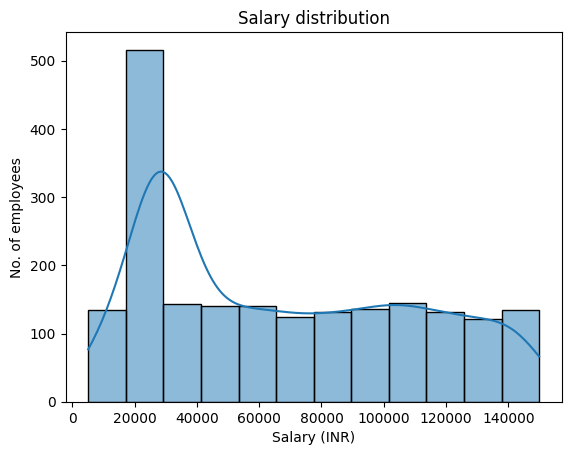

<Figure size 640x480 with 0 Axes>

In [72]:
sns.histplot(messy_data['Monthly Salary (INR)'] , kde=True)
plt.title("Salary distribution")
plt.xlabel("Salary (INR)")
plt.ylabel("No. of employees")
plt.show()
plt.savefig('salary_distribution.png')

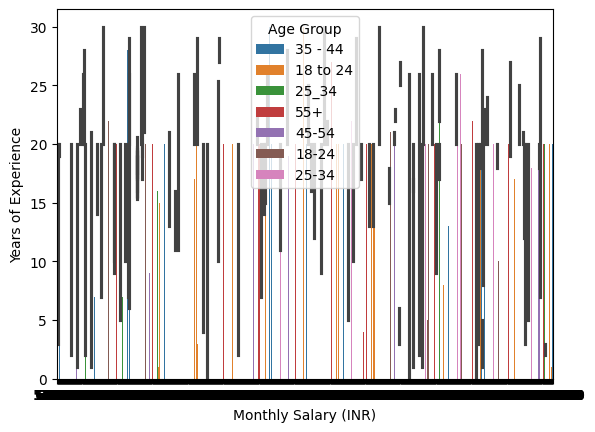

In [73]:
sns.barplot(messy_data,x='Monthly Salary (INR)' , y='Years of Experience' , hue='Age Group')
plt.show()

In [74]:
messy_data['Industry'].mode()[0]

'Retail'

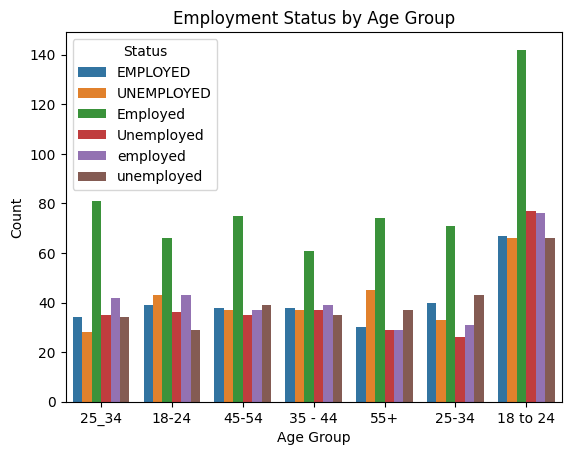

<Figure size 640x480 with 0 Axes>

In [75]:
sns.countplot(
    data=messy_data,
    x='Age Group',
    hue='Status'
)

plt.title('Employment Status by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()
plt.savefig('employment_status_by_age_group.png')

In [76]:
messy_data['Monthly Salary (INR)'].mean()

np.float64(67446.2)

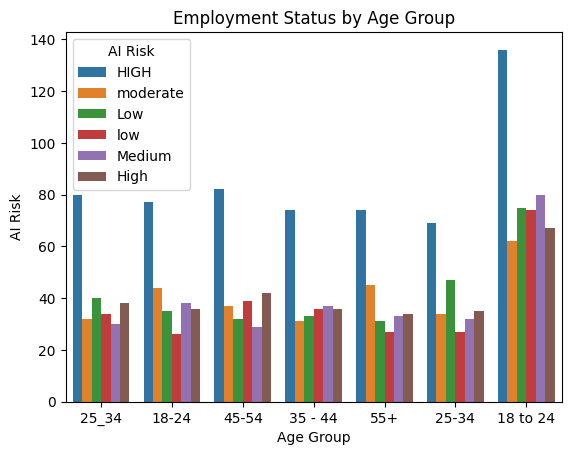

<Figure size 640x480 with 0 Axes>

In [77]:
sns.countplot(
    data=messy_data,
    x='Age Group',
    hue='AI Risk'
)

plt.title('Employment Status by Age Group')
plt.xlabel('Age Group')
plt.ylabel('AI Risk')
plt.show()
plt.savefig('AI_Risk_by_Age_Group.png')


From the above data analysis it is shown that the data I am using have following insights :

<br>The maximum salaries of Indians employees lies under Rs.20000 /- 
<br> The maximum number of employees works under Retail sector
<br> Avergae salary of employees in India is 67446
<br> Maximum number of employees are fall under age group of 18-25
<br> The highest risk of emplyees are in age group of 18-25 and the lowest ones are in age group of 55+